# 1 Warmup

In [1]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def build_mlp(input_dim=1, hidden_dim=64, depth=3, output_dim=1):
    """
    Build a standard MLP using nn.Sequential, with no custom classes.
    """
    layers = []
    in_dim = input_dim

    for _ in range(depth):
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())
        in_dim = hidden_dim

    layers.append(nn.Linear(in_dim, output_dim))

    model = nn.Sequential(*layers).to(device)
    return model


def forward_baseline(model, x):
    """
    Standard forward pass: f(x) = model(x)
    """
    x = x.to(device)
    return model(x)


def forward_symmetric(model, x):
    """
    Symmetry-constrained forward pass: f(x) = model(|x|)
    This guarantees f(x) = f(-x).
    """
    x = x.to(device)
    x_even = torch.abs(x)
    return model(x_even)


def count_parameters(model):
    """
    Count trainable parameters.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Build the two models
baseline_model = build_mlp(input_dim=1, hidden_dim=64, depth=3, output_dim=1)
symmetric_model = build_mlp(input_dim=1, hidden_dim=64, depth=3, output_dim=1)

print("Baseline parameter count:", count_parameters(baseline_model))
print("Symmetric parameter count:", count_parameters(symmetric_model))

Baseline parameter count: 8513
Symmetric parameter count: 8513


Same as a standard MLP except that its input is always replaced by $|x|$.

The architecture
$$
h_\theta(x) = g_\theta(|x|)
$$
always satisfies
$$
h_\theta(x) = h_\theta(-x).
$$


Final baseline test MSE:   0.002321
Final symmetric test MSE: 0.000533
Baseline symmetry error:   2.997968e-02
Symmetric symmetry error: 0.000000e+00


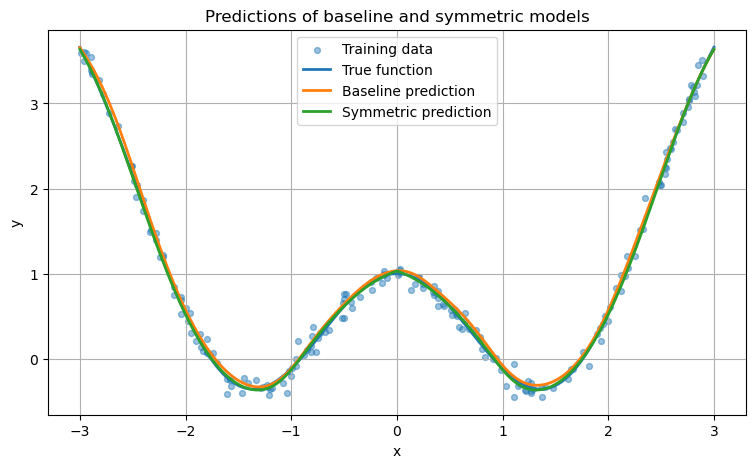

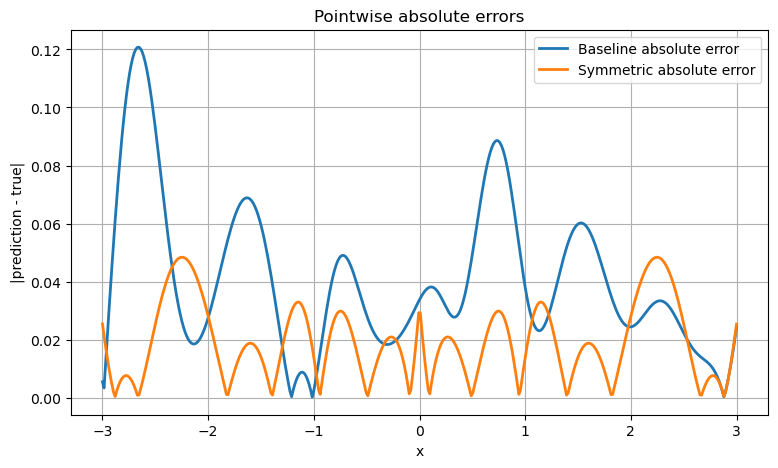

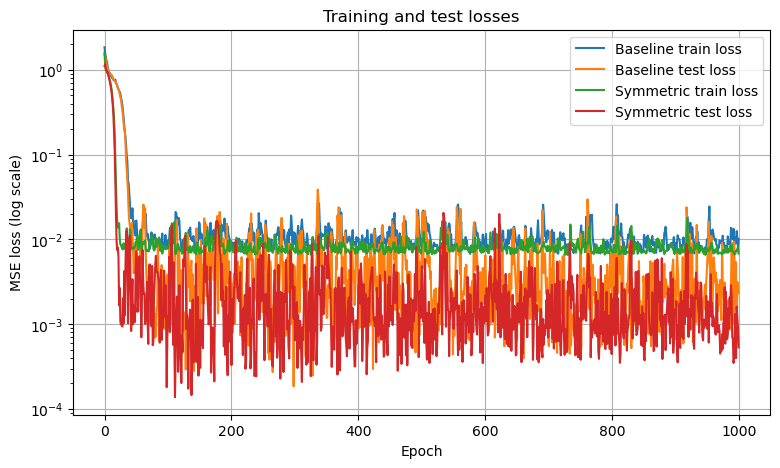

In [2]:
# training + testing + plotting

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(38)
np.random.seed(38)


def target_function(x):
    # Even function: f(x) = cos(2x) + 0.3 x^2
    return torch.cos(2 * x) + 0.3 * x**2

def make_dataset(n_train=200, n_test=400, x_range=3.0, noise_std=0.08):
    x_train = (2 * x_range) * torch.rand(n_train, 1) - x_range
    y_train = target_function(x_train) + noise_std * torch.randn_like(x_train)

    x_test = torch.linspace(-x_range, x_range, n_test).reshape(-1, 1)
    y_test = target_function(x_test)

    return x_train, y_train, x_test, y_test

def train_model(model, forward_fn, x_train, y_train, x_test, y_test,
                epochs=1000, batch_size=32, lr=1e-3):
    model.train()

    dataset = TensorDataset(x_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    train_losses = []
    test_losses = []

    x_test = x_test.to(device)
    y_test = y_test.to(device)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = forward_fn(model, xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.shape[0]

        avg_train_loss = running_loss / len(dataset)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            test_pred = forward_fn(model, x_test)
            test_loss = loss_fn(test_pred, y_test).item()
            test_losses.append(test_loss)

    return train_losses, test_losses

def predict(model, forward_fn, x):
    model.eval()
    with torch.no_grad():
        return forward_fn(model, x.to(device)).cpu()


def symmetry_error(model, forward_fn, x):
    model.eval()
    with torch.no_grad():
        y1 = forward_fn(model, x.to(device))
        y2 = forward_fn(model, (-x).to(device))
        return torch.mean(torch.abs(y1 - y2)).item()


x_train, y_train, x_test, y_test = make_dataset()

baseline_train_losses, baseline_test_losses = train_model(
    baseline_model,
    forward_baseline,
    x_train, y_train,
    x_test, y_test,
    epochs=1000,
    batch_size=32,
    lr=1e-3
)

symmetric_train_losses, symmetric_test_losses = train_model(
    symmetric_model,
    forward_symmetric,
    x_train, y_train,
    x_test, y_test,
    epochs=1000,
    batch_size=32,
    lr=1e-3
)


y_pred_baseline = predict(baseline_model, forward_baseline, x_test)
y_pred_symmetric = predict(symmetric_model, forward_symmetric, x_test)

abs_err_baseline = torch.abs(y_pred_baseline - y_test)
abs_err_symmetric = torch.abs(y_pred_symmetric - y_test)

baseline_mse = torch.mean((y_pred_baseline - y_test) ** 2).item()
symmetric_mse = torch.mean((y_pred_symmetric - y_test) ** 2).item()

baseline_sym = symmetry_error(baseline_model, forward_baseline, x_test)
symmetric_sym = symmetry_error(symmetric_model, forward_symmetric, x_test)

print(f"\nFinal baseline test MSE:   {baseline_mse:.6f}")
print(f"Final symmetric test MSE: {symmetric_mse:.6f}")
print(f"Baseline symmetry error:   {baseline_sym:.6e}")
print(f"Symmetric symmetry error: {symmetric_sym:.6e}")

plt.figure(figsize=(9, 5))
plt.scatter(
    x_train.numpy(),
    y_train.numpy(),
    s=18,
    alpha=0.45,
    label="Training data"
)
plt.plot(
    x_test.numpy(),
    y_test.numpy(),
    linewidth=2,
    label="True function"
)
plt.plot(
    x_test.numpy(),
    y_pred_baseline.numpy(),
    linewidth=2,
    label="Baseline prediction"
)
plt.plot(
    x_test.numpy(),
    y_pred_symmetric.numpy(),
    linewidth=2,
    label="Symmetric prediction"
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Predictions of baseline and symmetric models")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(9, 5))
plt.plot(
    x_test.numpy(),
    abs_err_baseline.numpy(),
    linewidth=2,
    label="Baseline absolute error"
)
plt.plot(
    x_test.numpy(),
    abs_err_symmetric.numpy(),
    linewidth=2,
    label="Symmetric absolute error"
)
plt.xlabel("x")
plt.ylabel("|prediction - true|")
plt.title("Pointwise absolute errors")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(9, 5))
plt.plot(baseline_train_losses, label="Baseline train loss")
plt.plot(baseline_test_losses, label="Baseline test loss")
plt.plot(symmetric_train_losses, label="Symmetric train loss")
plt.plot(symmetric_test_losses, label="Symmetric test loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE loss (log scale)")
plt.title("Training and test losses")
plt.legend()
plt.grid(True)
plt.show()





# 2 Designing Symmetry-Respecting Architectures

In [3]:
from the_well.utils.download import well_download

BASE_PATH = "./datasets"
DATASET = "turbulent_radiative_layer_2D"

# Download splits
well_download(base_path=BASE_PATH, dataset=DATASET, split="train")
well_download(base_path=BASE_PATH, dataset=DATASET, split="valid")  
well_download(base_path=BASE_PATH, dataset=DATASET, split="test")

### 1(a)

I use the turbulent_radiative_layer_2D dataset from TheWell.

Dimension of data: 2D spatial fields on a grid of size $H \times W$ with $C$ physical channels  
Task: one-step forecasting — given a field configuration $ \phi(t_i, x, y) $, predict the configuration at the next time step $ \phi(t_{i+1}, x, y) $

### 1(b)

I enforce horizontal translation equivariance. I choose this symmetry because the dataset has a distinguished vertical structure (different physical conditions at the top and bottom), so vertical translations change the state. 

Let $T_k$ denote a shift by $k$ grid points in the horizontal direction then
$$
f(T_k x) = T_k f(x)
$$

This ensures that the model treats all horizontal positions consistently and does not depend on absolute horizontal location.

### 2(a)

I construct a convolutional neural network that enforces horizontal translation equivariance.


The forward pass is 
$$
z^{(0)} = x
$$
$$
z^{(\ell+1)} = \sigma(\text{Conv}(z^{(\ell)}))
$$
$$
f(x) = z^{(L)}
$$

where each convolution is preceded by horizontal circular padding. So this model respects the symmetry in part 1(b).


### 2(b)

The model satisfies horizontal translation equivariance
$$
f(T_k x) = T_k f(x)
$$

where $T_k$ is a horizontal shift by $k$ grid points.

The result follows from three properties:

Applying a horizontal shift before or after circular padding produces the same result, since padding wraps values around periodically.

Convolution applies the same kernel at every location, so shifting the input results in an equally shifted output:
$$
\text{Conv}(T_k x) = T_k \text{Conv}(x)
$$

Since nonlinearities are applied independently at each location:
$$
\sigma(T_k x) = T_k \sigma(x)
$$

Since each layer satisfies the equivariance property, their composition also satisfies it so the entire network obeys
$$
f(T_k x) = T_k f(x)
$$


### 3(a)

I implement two models for the same one-step forecasting task on the turbulent_radiative_layer_2D dataset:

1. Symmetry-constrained model: a CNN with circular padding in the horizontal direction, which enforces horizontal translation equivariance.

2. Baseline model: same CNN but without circular horizontal padding.

Both models take an input field $x \in \mathbb{R}^{C \times H \times W}$ and predict the next field at the same spatial resolution. They are trained on the same training split and evaluated on the same validation/test split.


### 3(b)

Sanity check

Horizontally shift each sample by $k$ grid points using a shift operator $T_k$. Then compare $f(T_k x)$ and $T_k f(x)$


the symmetry error $\|f(T_k x) - T_k f(x)\|$ should be very zero for a model that respects the symmetry


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def build_conv_stack(in_channels, hidden_channels, out_channels, depth):
    layers = []

    layers.append(nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=0))
    layers.append(nn.GELU())

    for _ in range(depth - 2):
        layers.append(nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=0))
        layers.append(nn.GELU())

    layers.append(nn.Conv2d(hidden_channels, out_channels, kernel_size=3, padding=0))

    return nn.ModuleList(layers).to(DEVICE)


def pad_horizontal_circular(x, pad=1):
    x = F.pad(x, (pad, pad, 0, 0), mode="circular")
    x = F.pad(x, (0, 0, pad, pad), mode="reflect")
    return x


def pad_zero_same(x, pad=1):
    return F.pad(x, (pad, pad, pad, pad), mode="constant", value=0.0)


def forward_equivariant(model_layers, x):
    z = x
    for layer in model_layers:
        if isinstance(layer, nn.Conv2d):
            z = layer(pad_horizontal_circular(z, pad=1))
        else:
            z = layer(z)
    return z


def forward_baseline(model_layers, x):
    z = x
    for layer in model_layers:
        if isinstance(layer, nn.Conv2d):
            z = layer(pad_zero_same(z, pad=1))
        else:
            z = layer(z)
    return z


@torch.no_grad()
def equivariance_error(model_layers, forward_fn, x, shift=5):
    x = x.to(DEVICE)

    lhs = forward_fn(model_layers, torch.roll(x, shifts=shift, dims=-1))
    rhs = torch.roll(forward_fn(model_layers, x), shifts=shift, dims=-1)

    return (lhs - rhs).abs().mean().item()


x = torch.randn(4, 3, 32, 64, device=DEVICE)


equivariant_model = build_conv_stack(
    in_channels=3,
    hidden_channels=16,
    out_channels=3,
    depth=4
)

baseline_model = build_conv_stack(
    in_channels=3,
    hidden_channels=16,
    out_channels=3,
    depth=4
)


err_equiv = equivariance_error(
    equivariant_model,
    forward_equivariant,
    x,
    shift=7
)

err_base = equivariance_error(
    baseline_model,
    forward_baseline,
    x,
    shift=7
)

print("Equivariant model symmetry error:", err_equiv)
print("Baseline model symmetry error:", err_base)

Equivariant model symmetry error: 0.0
Baseline model symmetry error: 0.0014741827035322785


### 3(c)

Compare the symmetry-constrained model and the baseline model on the same one-step forecasting task.

Both models are trained on the same training split and evaluated on the same validation and test splits. The comparison includes:

- training loss
- validation loss
- test error
- prediction plots
- pointwise error plots

Full dataset sizes:
train: 7200
val:   900
test:  900

Subset sizes actually used:
train: 128
val:   32
test:  16

Input shape: torch.Size([4, 4, 128, 384])
Target shape: torch.Size([4, 4, 128, 384])

Equivariant params: 3492
Baseline params:    3492

Training equivariant model
Epoch 01 | train loss = 389.778334 | val loss = 78.574644
Epoch 02 | train loss = 36.588986 | val loss = 16.681731
Epoch 03 | train loss = 25.324904 | val loss = 13.761026

Training baseline model
Epoch 01 | train loss = 280.712527 | val loss = 25.299401
Epoch 02 | train loss = 33.359112 | val loss = 19.275145
Epoch 03 | train loss = 27.749186 | val loss = 16.050457

Final test MSE
Equivariant model: 10.222873330116272
Baseline model:    12.340644240379333


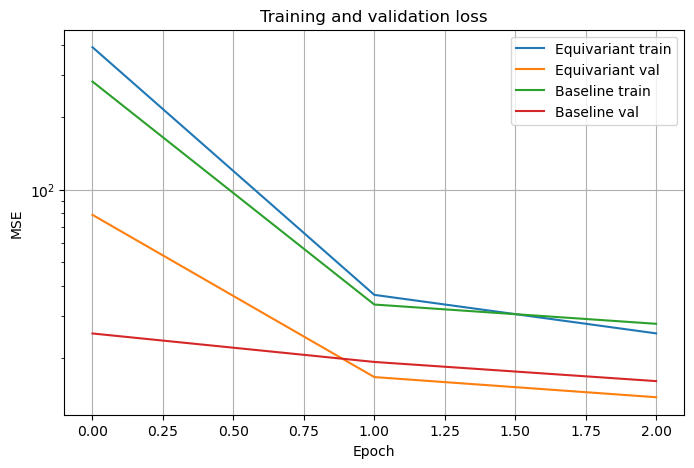

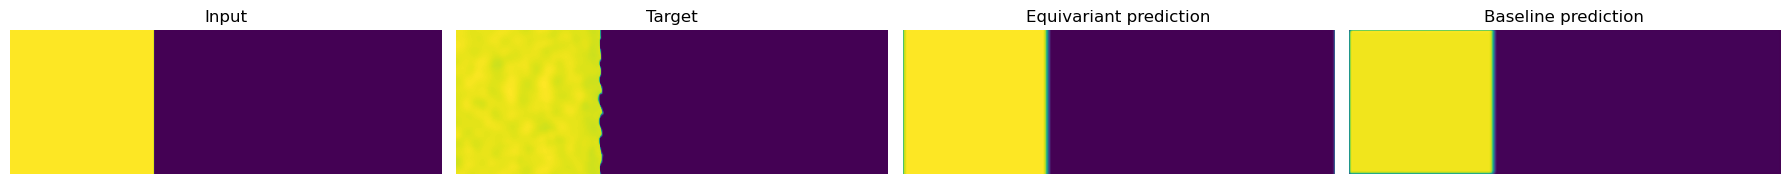

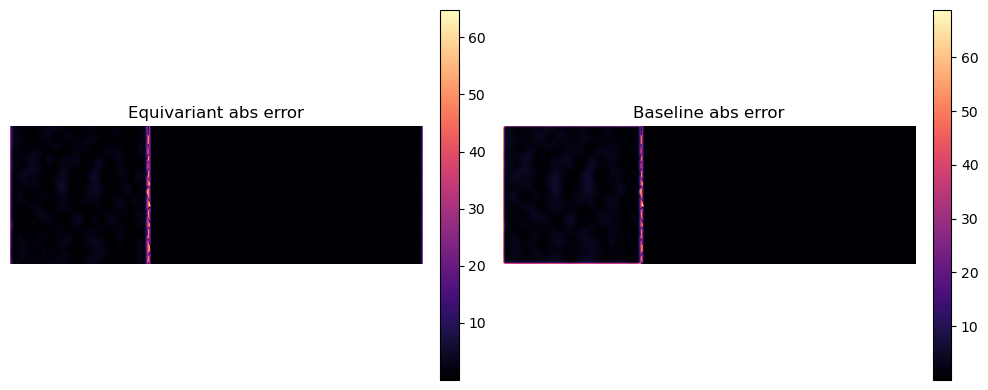

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from the_well.data import WellDataset


torch.manual_seed(38)
np.random.seed(38)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


BASE_PATH = "./datasets/datasets"
DATASET = "turbulent_radiative_layer_2D"
TRAIN_SPLIT = "train"
VAL_SPLIT = "valid"
TEST_SPLIT = "test"


train_dataset_full = WellDataset(
    well_base_path=BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name=TRAIN_SPLIT,
)

val_dataset_full = WellDataset(
    well_base_path=BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name=VAL_SPLIT,
)

test_dataset_full = WellDataset(
    well_base_path=BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name=TEST_SPLIT,
)

print("Full dataset sizes:")
print("train:", len(train_dataset_full))
print("val:  ", len(val_dataset_full))
print("test: ", len(test_dataset_full))


MAX_TRAIN = min(128, len(train_dataset_full))
MAX_VAL = min(32, len(val_dataset_full))
MAX_TEST = min(16, len(test_dataset_full))

train_dataset = Subset(train_dataset_full, range(MAX_TRAIN))
val_dataset = Subset(val_dataset_full, range(MAX_VAL))
test_dataset = Subset(test_dataset_full, range(MAX_TEST))

print("\nSubset sizes actually used:")
print("train:", len(train_dataset))
print("val:  ", len(val_dataset))
print("test: ", len(test_dataset))


def sample_to_xy(sample):
    """
    Uses one input snapshot and one target snapshot.

    Common expected shapes:
      input_fields:  [T_in, H, W, C]
      output_fields: [T_out, H, W, C]

    Returns:
      x: [C, H, W]
      y: [C, H, W]
    """
    x = sample["input_fields"][0]
    y = sample["output_fields"][0]


    x = torch.as_tensor(x, dtype=torch.float32).permute(2, 0, 1)
    y = torch.as_tensor(y, dtype=torch.float32).permute(2, 0, 1)
    return x, y

def collate_fn(batch):
    xs = []
    ys = []
    for sample in batch:
        x, y = sample_to_xy(sample)
        xs.append(x)
        ys.append(y)
    return torch.stack(xs, dim=0), torch.stack(ys, dim=0)

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)

x0, y0 = next(iter(train_loader))
IN_CHANNELS = x0.shape[1]
OUT_CHANNELS = y0.shape[1]

print("\nInput shape:", x0.shape)
print("Target shape:", y0.shape)


def build_conv_stack(in_channels, hidden_channels, out_channels, depth):
    layers = []

    layers.append(nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=0))
    layers.append(nn.GELU())

    for _ in range(depth - 2):
        layers.append(nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=0))
        layers.append(nn.GELU())

    layers.append(nn.Conv2d(hidden_channels, out_channels, kernel_size=3, padding=0))

    return nn.ModuleList(layers).to(DEVICE)

def pad_horizontal_circular(x, pad=1):
    # x: [B, C, H, W]
    x = F.pad(x, (pad, pad, 0, 0), mode="circular")  # horizontal / width
    x = F.pad(x, (0, 0, pad, pad), mode="reflect")   # vertical / height
    return x

def pad_zero_same(x, pad=1):
    return F.pad(x, (pad, pad, pad, pad), mode="constant", value=0.0)

def forward_equivariant(model_layers, x):
    z = x
    for layer in model_layers:
        if isinstance(layer, nn.Conv2d):
            z = layer(pad_horizontal_circular(z, pad=1))
        else:
            z = layer(z)
    return z

def forward_baseline(model_layers, x):
    z = x
    for layer in model_layers:
        if isinstance(layer, nn.Conv2d):
            z = layer(pad_zero_same(z, pad=1))
        else:
            z = layer(z)
    return z

def count_parameters(module_list):
    return sum(p.numel() for p in module_list.parameters() if p.requires_grad)

HIDDEN_CHANNELS = 16
DEPTH = 3

equivariant_model = build_conv_stack(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=OUT_CHANNELS,
    depth=DEPTH,
)

baseline_model = build_conv_stack(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=OUT_CHANNELS,
    depth=DEPTH,
)

print("\nEquivariant params:", count_parameters(equivariant_model))
print("Baseline params:   ", count_parameters(baseline_model))

def mse_on_loader(model_layers, forward_fn, loader):
    loss_fn = nn.MSELoss()
    total_loss = 0.0
    total_count = 0

    for layer in model_layers:
        layer.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            pred = forward_fn(model_layers, x)
            loss = loss_fn(pred, y)

            batch_size = x.shape[0]
            total_loss += loss.item() * batch_size
            total_count += batch_size

    return total_loss / total_count

def train_model(model_layers, forward_fn, train_loader, val_loader, epochs=3, lr=1e-3):
    optimizer = torch.optim.Adam(model_layers.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        for layer in model_layers:
            layer.train()

        total_train_loss = 0.0
        total_count = 0

        for x, y in train_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            pred = forward_fn(model_layers, x)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()

            batch_size = x.shape[0]
            total_train_loss += loss.item() * batch_size
            total_count += batch_size

        avg_train_loss = total_train_loss / total_count
        avg_val_loss = mse_on_loader(model_layers, forward_fn, val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train loss = {avg_train_loss:.6f} | "
            f"val loss = {avg_val_loss:.6f}"
        )

    return train_losses, val_losses

EPOCHS = 3
LR = 1e-3

print("\nTraining equivariant model")
equiv_train_losses, equiv_val_losses = train_model(
    equivariant_model,
    forward_equivariant,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
)

print("\nTraining baseline model")
base_train_losses, base_val_losses = train_model(
    baseline_model,
    forward_baseline,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
)

equiv_test_loss = mse_on_loader(equivariant_model, forward_equivariant, test_loader)
base_test_loss = mse_on_loader(baseline_model, forward_baseline, test_loader)

print("\nFinal test MSE")
print("Equivariant model:", equiv_test_loss)
print("Baseline model:   ", base_test_loss)


@torch.no_grad()
def get_one_batch_predictions(model_layers, forward_fn, loader):
    for layer in model_layers:
        layer.eval()

    x, y = next(iter(loader))
    x_device = x.to(DEVICE)
    pred = forward_fn(model_layers, x_device)

    return x.cpu(), y.cpu(), pred.cpu()

x_vis, y_vis, pred_equiv = get_one_batch_predictions(
    equivariant_model,
    forward_equivariant,
    test_loader,
)

_, _, pred_base = get_one_batch_predictions(
    baseline_model,
    forward_baseline,
    test_loader,
)

sample_id = 0
channel_id = 0

input_img = x_vis[sample_id, channel_id].numpy()
target_img = y_vis[sample_id, channel_id].numpy()
equiv_img = pred_equiv[sample_id, channel_id].numpy()
base_img = pred_base[sample_id, channel_id].numpy()

equiv_err = np.abs(equiv_img - target_img)
base_err = np.abs(base_img - target_img)


plt.figure(figsize=(8, 5))
plt.plot(equiv_train_losses, label="Equivariant train")
plt.plot(equiv_val_losses, label="Equivariant val")
plt.plot(base_train_losses, label="Baseline train")
plt.plot(base_val_losses, label="Baseline val")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()


fig, axs = plt.subplots(1, 4, figsize=(18, 4))

axs[0].imshow(input_img, cmap="viridis")
axs[0].set_title("Input")

axs[1].imshow(target_img, cmap="viridis")
axs[1].set_title("Target")

axs[2].imshow(equiv_img, cmap="viridis")
axs[2].set_title("Equivariant prediction")

axs[3].imshow(base_img, cmap="viridis")
axs[3].set_title("Baseline prediction")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()


fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im0 = axs[0].imshow(equiv_err, cmap="magma")
axs[0].set_title("Equivariant abs error")
axs[0].axis("off")
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(base_err, cmap="magma")
axs[1].set_title("Baseline abs error")
axs[1].axis("off")
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

I trained both models on the same one-step forecasting task using the same data subset, optimization method, learning rate, number of epochs, and parameter budget. The only architectural difference is that the symmetry-constrained model uses circular padding in the horizontal direction.

The final results were:

- Equivariant model test MSE: 10.22
- Baseline model test MSE: 12.34


These results show that the symmetry-constrained model achieved better predictive accuracy on both validation and test data.

For training only Adam optimizer, MSE loss, and a small CNN were used. 

Upon running the code with different random seeds. The model is robust to multiple seeds.

### 3(d)

The symmetry-constrained architecture generalized better than the baseline.

Only a small subset of the full training set was used. The model is forced to treat horizontally shifted versions of the same pattern consistently. This reduces the effective hypothesis space and improves sample efficiency.
Having the correct physical symmetry into the architecture can improve generalization and forecasting accuracy. The constrained model did outperform the baseline.